In [4]:
import cv2
import numpy as np
import os
from IPython.display import HTML
from base64 import b64encode


import cv2
import matplotlib.pyplot as plt

from PIL import Image

import cv2
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from skimage.morphology import area_closing, closing

import cv2
import numpy as np
# !pip install scikit-learn

import numpy as np
import cv2
from skimage.segmentation import slic
from scipy.spatial.distance import cdist

import pandas as pd
import random
import imageio


from transformers import CLIPImageProcessor, CLIPVisionModelWithProjection
from pipeline.pipeline import DualFlowControlNetPipeline
from train_utils.unimatch.unimatch.unimatch import UniMatch
from train_utils.dav2.depth_anything_v2.dpt import DepthAnythingV2
import torch.nn.functional as F
from train_utils.unimatch.utils.flow_viz import flow_to_image

import os
import torch
import numpy as np
from tqdm import tqdm
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from diffusers import AutoencoderKL
from diffusers import UNet2DConditionModel
from diffusers import ControlNetModel
import lpips
from skimage.metrics import structural_similarity as ssim
import math

from models.unet_spatio_temporal_condition_controlnet import UNetSpatioTemporalConditionControlNetModel
from diffusers import AutoencoderKLTemporalDecoder, EulerDiscreteScheduler, UNetSpatioTemporalConditionModel
from models.svdxt_featureflow_forward_controlnet_s2d_fixcmp_norefine import CMP_demo, DualFlowControlNet_traj

from safetensors.torch import load_file
from torch.utils.data import Dataset
import pickle

from torchmetrics.image.fid import FrechetInceptionDistance

from test_gpu import setup_cuda
import torch.nn as nn
from train_utils.sample_flow_utils import flow_sampler


import os
import torch
import random
import numpy as np
from PIL import Image
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UniPCMultistepScheduler,
    AutoencoderKL,
    UNet2DConditionModel,
    DDPMScheduler
)
from transformers import CLIPTextModel, CLIPTokenizer
import torch
import torch.nn.functional as F
from tqdm import tqdm


from diffusers import StableDiffusionControlNetPipeline

from diffusers import StableVideoDiffusionPipeline

from my_datasets import DatasetMultimodalVideo, DatasetRetinaVideo

from kohya_lora import LoRANetwork


In [5]:


def to_one_hot(mask, num_classes=1):
    """
    mask: (H, W) uint8
    returns: (C, H, W) uint8
    """
    one_hot = np.zeros((num_classes, *mask.shape), dtype=np.uint8)
    one_hot[mask, np.arange(mask.shape[0])[:, None], np.arange(mask.shape[1])] = 1
    return one_hot



@torch.no_grad()
def evaluate_manual(
    out_onehot,
    checkpoint_path,
    pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5",
    output_dir="results/eval_manual",
    num_samples=0,
    num_inference_steps=30,
    device="cpu",
    image_size=256,
):


    # This works for adding LoRa 2D style

    # ---------------------------
    # torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    torch_dtype = torch.float32

    print("[INFO] Loading pretrained components...")
    tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
    text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device, dtype=torch_dtype)
    vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae").to(device, dtype=torch_dtype)
    unet = UNet2DConditionModel.from_pretrained(pretrained_model_name_or_path, subfolder="unet").to(device, dtype=torch_dtype)
    controlnet = ControlNetModel.from_pretrained(checkpoint_path, torch_dtype=torch_dtype).to(device)

    noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name_or_path, subfolder="scheduler")

    vae.eval()
    unet.eval()
    controlnet.eval()
    text_encoder.eval()

    print(vae.config.scaling_factor)
# 

    # ---------------------------
    # 3️⃣ Diffusion sampling loop
    # ---------------------------


    lora_path = "/home/MichalMo/projects/SurgSora/kohya_ss/outputs/cataract2-000026.safetensors"
    lora_sd = load_file(lora_path, device=device)

    lora = LoRANetwork(
        text_encoder=None,
        unet=unet
    ).to(device)

    lora.load_state_dict(lora_sd, strict=False)

    lora.apply_to(None, unet)

    unet.to(device)
    controlnet.unet = unet
    controlnet.to(device)

    for module in lora.modules():
        module.to(device)

    for name, param in controlnet.unet.named_parameters():
        if param.device.type != "cuda:0":
            print("CPU param:", name)
            break

        
    # cond = sample["mask"].unsqueeze(0).to(device, dtype=torch_dtype)  # [1,14,H,W]
    cond = torch.tensor(out_onehot.astype(np.float32)).unsqueeze(0).to(device)
    print(cond.shape, cond.dtype)

    prompt = "retina image"

    # print(sample["file_name"])

    # Tokenize prompt → CLIP hidden states
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    ).to(device)
    encoder_hidden_states = text_encoder(text_inputs.input_ids)[0]  # [1,77,768]

    # Initialize random latent (the "image" in latent space)
    latents = torch.randn(
        (1, unet.in_channels, image_size // 8, image_size // 8),
        device=device,
        dtype=torch_dtype,
    )

    # Prepare scheduler
    noise_scheduler.set_timesteps(num_inference_steps)
    # print(f"[INFO] Sampling with {num_inference_steps} steps...")

    for t in tqdm(noise_scheduler.timesteps, desc=f"Sample {+1}/{num_samples}"):
        # Predict noise using ControlNet + UNet
        t= t.to(device)
        # print(latents.device, t.device, encoder_hidden_states.device,cond.device )
        down_block_res_samples, mid_block_res_sample = controlnet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            controlnet_cond=cond,
            return_dict=False,
        )

        noise_pred = unet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            down_block_additional_residuals=[
                sample.to(dtype=torch_dtype) for sample in down_block_res_samples
            ],
            mid_block_additional_residual=mid_block_res_sample.to(dtype=torch_dtype),
            return_dict=False,
        )[0]

        # Step with scheduler
        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    # ---------------------------
    # 4️⃣ Decode latents → image
    # ---------------------------
    latents = 1 / vae.config.scaling_factor * latents
    image_decoded = vae.decode(latents).sample  # [1,3,H,W]

    # print(image_decoded.shape, image_decoded.dtype, torch.min(image_decoded), torch.max(image_decoded))

    # Map from [-1,1] → [0,1]
    # image = (image.clamp(-1, 1) + 1) / 2.0
    image = (image_decoded / 2 + 0.5).clamp(0, 1)
    # print(image.shape, image.dtype, torch.min(image), torch.max(image))

    image = image.float()

    # print(image.shape, image.dtype, torch.min(image), torch.max(image))
    image = (image - image.min()) / (image.max() - image.min() + 1e-5)
    return image



@torch.no_grad()
def evaluate_manual_with_lora(
    out_onehot,
    checkpoint_path,
    pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5",
    output_dir="results/eval_manual",
    num_samples=0,
    num_inference_steps=30,
    device="cpu",
    image_size=256,
):


    # This works for adding LoRa 2D style

    # ---------------------------
    # torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    torch_dtype = torch.float32

    print("[INFO] Loading pretrained components...")
    tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
    text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device, dtype=torch_dtype)
    vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae").to(device, dtype=torch_dtype)
    unet = UNet2DConditionModel.from_pretrained(pretrained_model_name_or_path, subfolder="unet").to(device, dtype=torch_dtype)
    controlnet = ControlNetModel.from_pretrained(checkpoint_path, torch_dtype=torch_dtype).to(device)

    noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name_or_path, subfolder="scheduler")

    vae.eval()
    unet.eval()
    controlnet.eval()
    text_encoder.eval()

    print(vae.config.scaling_factor)
# 

    # ---------------------------
    # 3️⃣ Diffusion sampling loop
    # ---------------------------


    lora_path = "/home/MichalMo/projects/SurgSora/kohya_ss/outputs/cataract2-000026.safetensors"
    lora_sd = load_file(lora_path, device=device)

    lora = LoRANetwork(
        text_encoder=None,
        unet=unet
    ).to(device)

    lora.load_state_dict(lora_sd, strict=False)

    lora.apply_to(None, unet)

    unet.to(device)
    controlnet.unet = unet
    controlnet.to(device)

    for module in lora.modules():
        module.to(device)

    for name, param in controlnet.unet.named_parameters():
        if param.device.type != "cuda:0":
            print("CPU param:", name)
            break

        
    # cond = sample["mask"].unsqueeze(0).to(device, dtype=torch_dtype)  # [1,14,H,W]
    cond = torch.tensor(out_onehot.astype(np.float32)).unsqueeze(0).to(device)
    print(cond.shape, cond.dtype)

    prompt = "retina image"

    # print(sample["file_name"])

    # Tokenize prompt → CLIP hidden states
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    ).to(device)
    encoder_hidden_states = text_encoder(text_inputs.input_ids)[0]  # [1,77,768]

    # Initialize random latent (the "image" in latent space)
    latents = torch.randn(
        (1, unet.in_channels, image_size // 8, image_size // 8),
        device=device,
        dtype=torch_dtype,
    )

    # Prepare scheduler
    noise_scheduler.set_timesteps(num_inference_steps)
    # print(f"[INFO] Sampling with {num_inference_steps} steps...")

    for t in tqdm(noise_scheduler.timesteps, desc=f"Sample {+1}/{num_samples}"):
        # Predict noise using ControlNet + UNet
        t= t.to(device)
        # print(latents.device, t.device, encoder_hidden_states.device,cond.device )
        down_block_res_samples, mid_block_res_sample = controlnet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            controlnet_cond=cond,
            return_dict=False,
        )

        noise_pred = unet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            down_block_additional_residuals=[
                sample.to(dtype=torch_dtype) for sample in down_block_res_samples
            ],
            mid_block_additional_residual=mid_block_res_sample.to(dtype=torch_dtype),
            return_dict=False,
        )[0]

        # Step with scheduler
        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    # ---------------------------
    # 4️⃣ Decode latents → image
    # ---------------------------
    latents = 1 / vae.config.scaling_factor * latents
    image_decoded = vae.decode(latents).sample  # [1,3,H,W]

    # print(image_decoded.shape, image_decoded.dtype, torch.min(image_decoded), torch.max(image_decoded))

    # Map from [-1,1] → [0,1]
    # image = (image.clamp(-1, 1) + 1) / 2.0
    image = (image_decoded / 2 + 0.5).clamp(0, 1)
    # print(image.shape, image.dtype, torch.min(image), torch.max(image))

    image = image.float()

    # print(image.shape, image.dtype, torch.min(image), torch.max(image))
    image = (image - image.min()) / (image.max() - image.min() + 1e-5)
    return image


przemek_to_cataract_map = {
    0:2,
    1:0, 
    2:0,
    3:1,
    5:0,
    6:5,
}





cataract_to_przemek_map = dict((v,k) for k,v in przemek_to_cataract_map.items())
print(cataract_to_przemek_map)

def przemek_to_cataract_fun(input):


    input = input.astype(np.uint8)

    output = np.arange(256, dtype=np.uint8)
    for k, v in przemek_to_cataract_map.items():
        output[k] = v
    return output[input]

{2: 0, 0: 5, 1: 3, 5: 6}


# SD model trained on 

In [11]:
# controlnet_path1 = "/home/MichalMo/projects/ControlNet-diffusers/cataract_mysplit_1/checkpoint-121260/controlnet"
controlnet_path1 = "/home/MichalMo/projects/SurgSora/Training/logs/train_stage1_records_r2_mask_weights_mod/checkpoint-6049/controlnet"

st = 20
indexes = list(range(st, st+1))
weight_dtype = torch.float32
device = "cuda:0"



test_dataset = DatasetMultimodalVideo(image_size=256,
                                    main_path=f'/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files',
                                    record = "r2", num_frames= 1, limit_frames = None)

BATCH = test_dataset.get_batch(indexes=indexes)
# video_name = f"video_{test_dataset.record}_{indexes[0]}_{indexes[1] + test_dataset.num_frames}"

# print(x[1].shape)
# print(video_name)



# print("VIDEO NAME ", video_name)
val_pixel_values = torch.Tensor(BATCH[0]).unsqueeze(0)

val_pixel_values = val_pixel_values.to(weight_dtype).to(device)  # [B, F, C, W, H]
print("val_pixel_values ", val_pixel_values.shape)




##################
image = val_pixel_values[0,0,...]
mask = torch.Tensor(BATCH[1]).unsqueeze(0)[0,0,...]
print(mask.shape, np.unique(mask.numpy()))

mask_cat = przemek_to_cataract_fun(mask.numpy())
print(mask_cat.shape, np.unique(mask_cat), mask_cat.dtype)


mask_cat_onehot = to_one_hot(mask_cat, num_classes=14).astype(np.float32)
print(mask_cat_onehot.shape, np.unique(mask_cat_onehot), mask_cat_onehot.dtype)


# mask_cat_onehot = torch.ones([1,21,])

r = evaluate_manual_with_lora(mask_cat_onehot, 
                checkpoint_path=controlnet_path1,

                output_dir="",
                num_samples=1,
                num_inference_steps=100,
                image_size=256,
                device = "cuda:0")

print("--")
# r = (r[0].cpu().numpy().transpose(1,2,0)*255.0).astype(np.uint8)
# print("r ", r.shape)


Loaded 134 samples
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8] uint8
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...


The config attributes {'num_frames': 25, 'out_channels': 4, 'sample_size': None, 'up_block_types': ['UpBlockSpatioTemporal', 'CrossAttnUpBlockSpatioTemporal', 'CrossAttnUpBlockSpatioTemporal', 'CrossAttnUpBlockSpatioTemporal']} were passed to ControlNetModel, but are not expected and will be ignored. Please verify your config.json configuration file.


ValueError: CrossAttnDownBlockSpatioTemporal does not exist.

Loaded 134 samples
[20]
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8]
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...


/home/MichalMo/anaconda3/envs/surgsora3_v2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


0.18215
create LoRA network. base dim (rank): 4, alpha: 1
neuron dropout: p=None, rank dropout: p=None, module dropout: p=None
create LoRA for U-Net: 0 modules.
enable LoRA for text encoder
enable LoRA for U-Net
CPU param: conv_in.weight
torch.Size([1, 14, 256, 256]) torch.float32


/tmp/ipykernel_2617886/3295300287.py:96: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, unet.in_channels, image_size // 8, image_size // 8),
Sample 1/1: 100%|██████████| 100/100 [00:11<00:00,  8.46it/s]


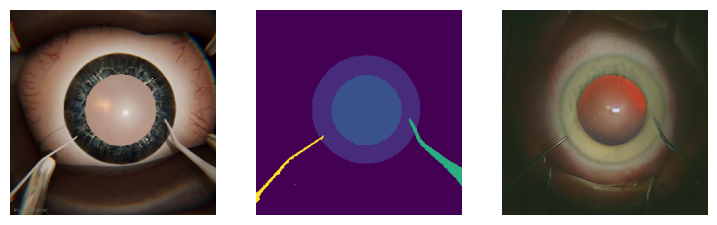

[21]
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8]
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...


/home/MichalMo/anaconda3/envs/surgsora3_v2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/tmp/ipykernel_2617886/3295300287.py:96: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, unet.in_channels, image_size // 8, image_size // 8),


0.18215
create LoRA network. base dim (rank): 4, alpha: 1
neuron dropout: p=None, rank dropout: p=None, module dropout: p=None
create LoRA for U-Net: 0 modules.
enable LoRA for text encoder
enable LoRA for U-Net
CPU param: conv_in.weight
torch.Size([1, 14, 256, 256]) torch.float32


Sample 1/1: 100%|██████████| 100/100 [00:07<00:00, 13.88it/s]


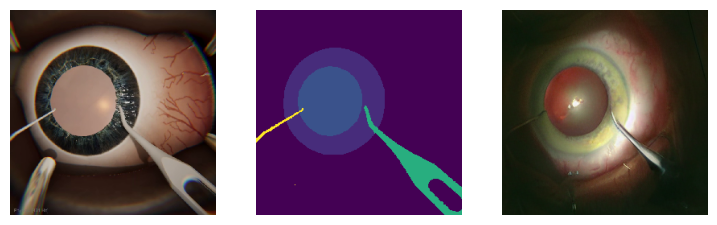

[22]
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8]
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...
0.18215
create LoRA network. base dim (rank): 4, alpha: 1
neuron dropout: p=None, rank dropout: p=None, module dropout: p=None
create LoRA for U-Net: 0 modules.
enable LoRA for text encoder
enable LoRA for U-Net
CPU param: conv_in.weight
torch.Size([1, 14, 256, 256]) torch.float32


Sample 1/1: 100%|██████████| 100/100 [00:06<00:00, 15.44it/s]


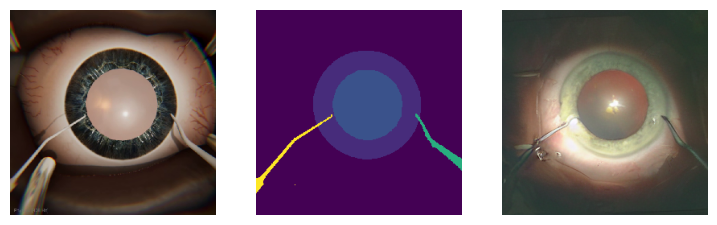

[23]
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8]
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...
0.18215
create LoRA network. base dim (rank): 4, alpha: 1
neuron dropout: p=None, rank dropout: p=None, module dropout: p=None
create LoRA for U-Net: 0 modules.
enable LoRA for text encoder
enable LoRA for U-Net
CPU param: conv_in.weight
torch.Size([1, 14, 256, 256]) torch.float32


Sample 1/1: 100%|██████████| 100/100 [00:06<00:00, 14.44it/s]


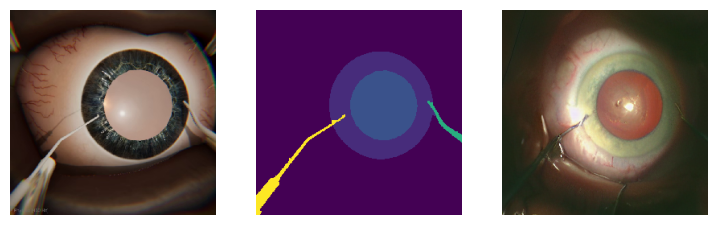

[24]
val_pixel_values  torch.Size([1, 1, 3, 256, 256])
torch.Size([256, 256]) [0. 1. 2. 3. 5. 6. 8.]
(256, 256) [0 1 2 5 8]
(14, 256, 256) [0. 1.] float32
[INFO] Loading pretrained components...
0.18215
create LoRA network. base dim (rank): 4, alpha: 1
neuron dropout: p=None, rank dropout: p=None, module dropout: p=None
create LoRA for U-Net: 0 modules.
enable LoRA for text encoder
enable LoRA for U-Net
CPU param: conv_in.weight
torch.Size([1, 14, 256, 256]) torch.float32


Sample 1/1: 100%|██████████| 100/100 [00:06<00:00, 14.29it/s]


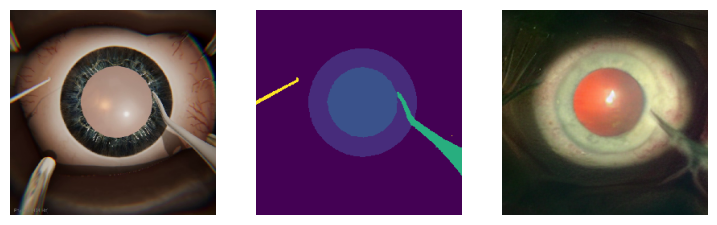

In [10]:
controlnet_path1 = "/home/MichalMo/projects/ControlNet-diffusers/cataract_mysplit_1/checkpoint-121260/controlnet"
# controlnet_path1 = "/home/MichalMo/projects/SurgSora/Training/logs/train_stage1_records_r2_mask_weights_mod/checkpoint-6049/controlnet"

st = 20
indexes = list(range(st, st+1))
weight_dtype = torch.float32
device = "cuda:0"

test_dataset = DatasetMultimodalVideo(image_size=256,
                                    main_path=f'/home/MichalMo/projects/ControlNet-diffusers/records_cadis_1/records_single_files',
                                    record = "r2", num_frames= 11, limit_frames = None)

st_list = [20,21,22,23,24]



for i in range(5):
    st = st_list[i]

    indexes = list(range(st, st+1))
    print(indexes)

    BATCH = test_dataset.get_batch(indexes=indexes)
    # video_name = f"video_{test_dataset.record}_{indexes[0]}_{indexes[1] + test_dataset.num_frames}"

    # print(x[1].shape)
    # print(video_name)



    # print("VIDEO NAME ", video_name)
    val_pixel_values = torch.Tensor(BATCH[0]).unsqueeze(0)

    val_pixel_values = val_pixel_values.to(weight_dtype).to(device)  # [B, F, C, W, H]
    print("val_pixel_values ", val_pixel_values.shape)




    ##################
    image = val_pixel_values[0,0,...]
    mask = torch.Tensor(BATCH[1]).unsqueeze(0)[0,0,...]
    print(mask.shape, np.unique(mask.numpy()))

    mask_cat = przemek_to_cataract_fun(mask.numpy())
    print(mask_cat.shape, np.unique(mask_cat))


    mask_cat_onehot = to_one_hot(mask_cat, num_classes=14).astype(np.float32)
    print(mask_cat_onehot.shape, np.unique(mask_cat_onehot), mask_cat_onehot.dtype)


    # mask_cat_onehot = torch.ones([1,21,])

    r = evaluate_manual_with_lora(mask_cat_onehot, 
                    checkpoint_path=controlnet_path1,

                    output_dir="",
                    num_samples=1,
                    num_inference_steps=100,
                    image_size=256,
                    device = "cuda")

    r = (r[0].cpu().numpy().transpose(1,2,0)*255.0).astype(np.uint8)
    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.imshow(image.cpu().numpy().transpose(1,2,0).astype(np.float32))
    plt.axis("off")

    plt.subplot(132)
    plt.imshow(mask_cat)
    plt.axis("off")

    plt.subplot(133)
    plt.imshow(r)
    plt.axis("off")
    plt.show()